# 145 — 모델 계열 비교: ML(lookup · LightGBM) 대 DL(GRU V3) × 가용성 4종

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`compare.py`가 남긴 지표 parquet을 **그림으로만** 다시 읽는다.

이 비교가 새로 답하는 것 — 198은 계열 수치를 **시드 3회 표준편차**로 냈고, 142는 "개선율 CI 폭이
≈4%p라 1~4%p 차이는 점추정으로 판별 불가"를 145로 넘겼다. 시드 분산과 날짜 분산은 다른 축이라
여기서 **날짜 블록 쌍 부트스트랩**으로 계열 차이에 구간을 붙인다.

| 축 | 값 |
| --- | --- |
| 계열 | `lookup` · `lightgbm`(배포 세트) · `gru_s42/43/44`(198 채택 V3, 시드 3개) |
| 가용성 | `full` · `d7_only` · `d1_only` · `no_lag` (`masking.SCENARIOS`) |
| 평가 | 2025 전체 1,992,900행(공통 행 100%), 부트스트랩 1,000회 |
| 발산 처리 | `raw`(주 표) — 144·198·MODEL_REGISTRY와 나란히 읽히게. `clip` 민감도는 RESULTS 5절 |

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "family_check"
a = pd.read_parquet(VAL / "family_check_A_lookup_대비_개선율_CI.parquet")
b = pd.read_parquet(VAL / "family_check_B_lightgbm_쌍차이.parquet")
c = pd.read_parquet(VAL / "family_check_C_발산처리_적용행.parquet")


def _opt(name):
    p = VAL / f"family_check_{name}.parquet"
    return pd.read_parquet(p) if p.exists() else None


d = _opt("D_등급_일치율")
e = _opt("E_추론_시간")

SC = ["full", "d7_only", "d1_only", "no_lag"]
SEEDS = ["gru_s42", "gru_s43", "gru_s44"]
TARGETS = ["boarding", "alighting"]
KOR = {"boarding": "승차", "alighting": "하차"}
tot_a = a[a["axis"] == "전체"]
tot_b = b[b["axis"] == "전체"]

print(f"발산 처리: {c['mode'].unique()[0]} · 상한 초과 행 합계 {int(c['상한초과_행'].sum())}")
print(f"평가 행 {tot_a['n_rows'].max():,} · 날짜 {tot_a['n_dates'].max()}일")
print(f"등급 표: {'있음' if d is not None else '없음'} · 추론 시간: {'있음' if e is not None else '없음'}")

발산 처리: raw · 상한 초과 행 합계 0
평가 행 1,992,900 · 날짜 365일
등급 표: 있음 · 추론 시간: 있음


## 1. 가용성 시나리오별 lookup 대비 개선율

LightGBM은 시차가 빠지면 lookup 아래로 떨어지고(`d7_only` −21%, `no_lag` −37%), GRU는 어느
시나리오에서도 0 위에 남는다. 오차막대는 날짜 블록 부트스트랩 95% CI다.

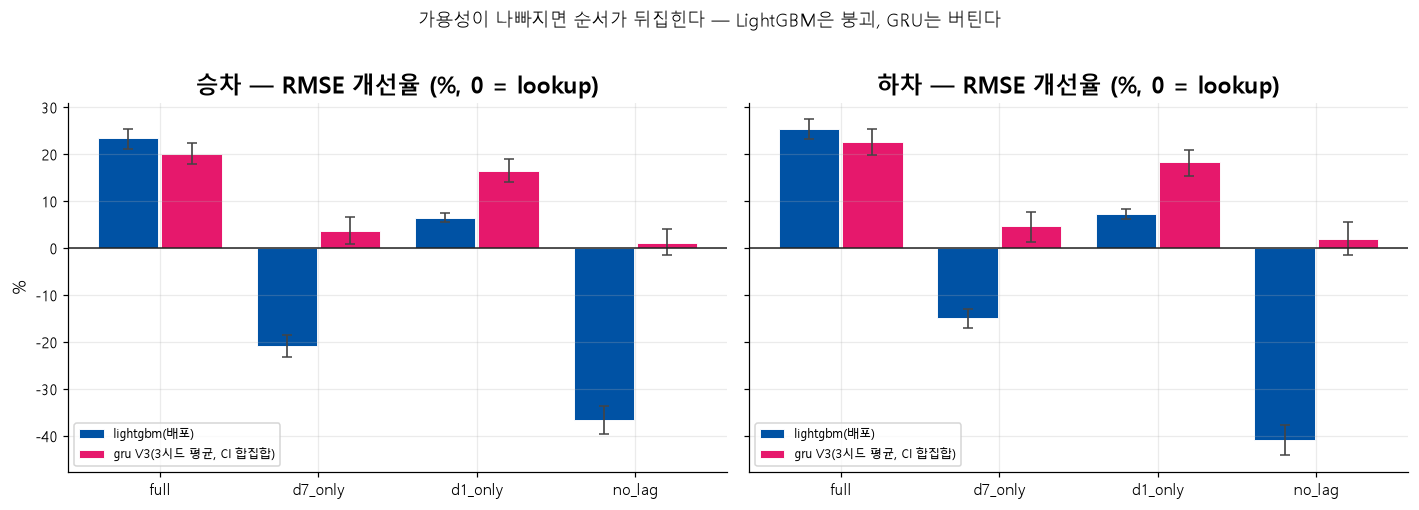

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
xx = np.arange(len(SC))

for ax, t in zip(axes, TARGETS):
    lgb = tot_a[(tot_a["series"] == "lightgbm") & (tot_a["target"] == t)].set_index("scenario")
    lgb = lgb.reindex(SC)
    point = lgb["RMSE_개선율_%"].to_numpy()
    err = [point - lgb["RMSE_CI_low"].to_numpy(), lgb["RMSE_CI_high"].to_numpy() - point]
    ax.bar(xx - 0.2, point, 0.38, yerr=err, capsize=3, label="lightgbm(배포)",
           color=figstyle.COLOR_MODEL, edgecolor="white", linewidth=0.6,
           error_kw={"ecolor": "#444", "elinewidth": 1.1})
    gru = tot_a[(tot_a["series"].isin(SEEDS)) & (tot_a["target"] == t)]
    mean = gru.groupby("scenario", observed=True)["RMSE_개선율_%"].mean().reindex(SC).to_numpy()
    lo = gru.groupby("scenario", observed=True)["RMSE_CI_low"].min().reindex(SC).to_numpy()
    hi = gru.groupby("scenario", observed=True)["RMSE_CI_high"].max().reindex(SC).to_numpy()
    ax.bar(xx + 0.2, mean, 0.38, yerr=[mean - lo, hi - mean], capsize=3,
           label="gru V3(3시드 평균, CI 합집합)", color=figstyle.COLOR_ACCENT,
           edgecolor="white", linewidth=0.6, error_kw={"ecolor": "#444", "elinewidth": 1.1})
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.set_xticks(xx)
    ax.set_xticklabels(SC)
    ax.set_title(f"{KOR[t]} — RMSE 개선율 (%, 0 = lookup)")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("%")
fig.suptitle("가용성이 나빠지면 순서가 뒤집힌다 — LightGBM은 붕괴, GRU는 버틴다", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "family_scenarios")

## 2. GRU − LightGBM 쌍 차이 [95% CI]

같은 재표본에서 두 계열을 같이 계산한 차이다. 빨간 선(+2%p)이 계열 교체 문턱,
0 아래면 LightGBM이 낫다는 뜻이다.

                    point_diff_RMSE_%p(계열-LightGBM)  diff_RMSE_CI_low  point_diff_MAE_%p(계열-LightGBM)  diff_MAE_CI_low
scenario target                                                                                                       
full     alighting                            -2.03             -3.67                            0.67            -0.82
         boarding                             -2.92             -4.42                            0.10            -1.52
d7_only  alighting                            20.47             17.81                           79.39            74.74
         boarding                             25.51             22.89                           80.90            75.73
d1_only  alighting                            11.60              9.73                           16.63            14.82
         boarding                             10.56              8.94                           15.72            13.86
no_lag   alighting                            44

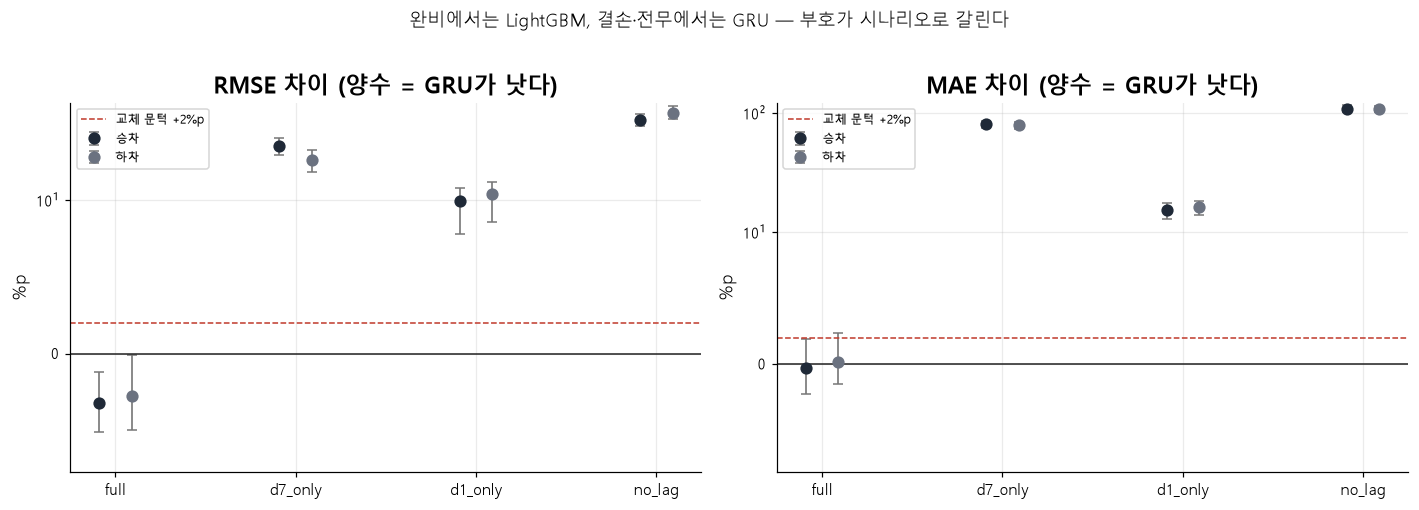

In [3]:
DIFF_R = "point_diff_RMSE_%p(계열-LightGBM)"
DIFF_M = "point_diff_MAE_%p(계열-LightGBM)"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (col, lo_col, hi_col, label) in zip(
    axes,
    [
        (DIFF_R, "diff_RMSE_CI_low", "diff_RMSE_CI_high", "RMSE"),
        (DIFF_M, "diff_MAE_CI_low", "diff_MAE_CI_high", "MAE"),
    ],
):
    for i, t in enumerate(TARGETS):
        sub = tot_b[tot_b["target"] == t]
        point = sub.groupby("scenario", observed=True)[col].mean().reindex(SC).to_numpy()
        lo = sub.groupby("scenario", observed=True)[lo_col].min().reindex(SC).to_numpy()
        hi = sub.groupby("scenario", observed=True)[hi_col].max().reindex(SC).to_numpy()
        ax.errorbar(xx + (i - 0.5) * 0.18, point, yerr=[point - lo, hi - point], fmt="o",
                    markersize=7, capsize=3, label=KOR[t],
                    color=figstyle.PALETTE_NEUTRAL[i], ecolor="#777", elinewidth=1.1)
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.axhline(2, color="#C0392B", linewidth=1.0, linestyle="--", label="교체 문턱 +2%p")
    ax.set_xticks(xx)
    ax.set_xticklabels(SC)
    ax.set_ylabel("%p")
    ax.set_yscale("symlog", linthresh=10)
    ax.set_title(f"{label} 차이 (양수 = GRU가 낫다)")
    ax.legend(fontsize=8)
fig.suptitle("완비에서는 LightGBM, 결손·전무에서는 GRU — 부호가 시나리오로 갈린다", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "family_paired_diff")

print(tot_b[tot_b["series"] == "gru_s42"].set_index(["scenario", "target"])[
    [DIFF_R, "diff_RMSE_CI_low", DIFF_M, "diff_MAE_CI_low"]
].round(2).to_string())

## 3. `full`에서 GRU는 어디서 지나 — 호선·요일유형

1호선이 GRU의 최대 약점(−9~10%p)이다. 같은 1호선에서 통계 모형은 LightGBM을 +15~17%p **앞섰다**
(`stat-model-check/RESULTS.md` 3절) — 1호선은 선형 시차가 특히 잘 맞고 시퀀스가 특히 못 맞는 노선이다.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_33352\3749754501.py:26: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()
C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


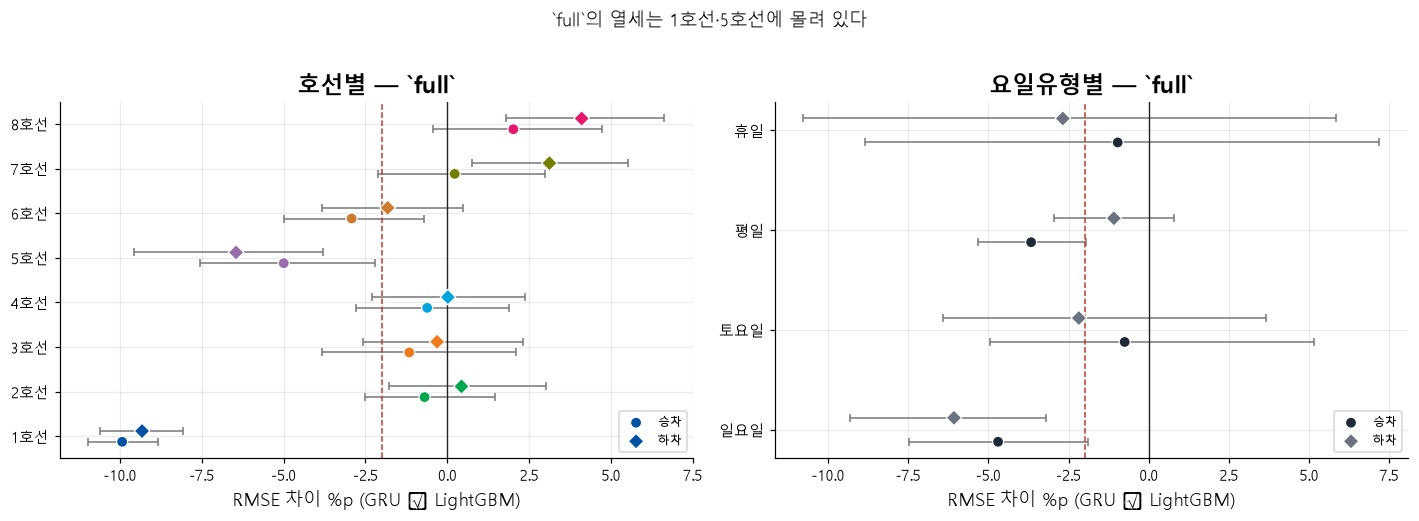

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, axis_name in zip(axes, ["호선", "요일유형"]):
    sub = b[(b["axis"] == axis_name) & (b["scenario"] == "full") & (b["series"] == "gru_s42")]
    groups = sorted(sub["group"].unique())
    yy = np.arange(len(groups))
    for i, t in enumerate(TARGETS):
        part = sub[sub["target"] == t].set_index("group").reindex(groups)
        point = part[DIFF_R].to_numpy()
        lo = point - part["diff_RMSE_CI_low"].to_numpy()
        hi = part["diff_RMSE_CI_high"].to_numpy() - point
        colors = ([figstyle.LINE_COLORS.get(g, "#666") for g in groups]
                  if axis_name == "호선" else [figstyle.PALETTE_NEUTRAL[i]] * len(groups))
        ax.errorbar(point, yy + (i - 0.5) * 0.24, xerr=[lo, hi], fmt="none",
                    ecolor="#777", elinewidth=1.0, capsize=2.5)
        ax.scatter(point, yy + (i - 0.5) * 0.24, s=52, c=colors,
                   marker="o" if i == 0 else "D", edgecolor="white", linewidth=0.8,
                   label=KOR[t], zorder=3)
    ax.axvline(0, color="#222", linewidth=0.9)
    ax.axvline(-2, color="#C0392B", linewidth=1.0, linestyle="--")
    ax.set_yticks(yy)
    ax.set_yticklabels(groups)
    ax.set_xlabel("RMSE 차이 %p (GRU − LightGBM)")
    ax.set_title(f"{axis_name}별 — `full`")
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("`full`의 열세는 1호선·5호선에 몰려 있다", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "family_full_slices")

## 4. 시드 분산과 날짜 CI는 다른 축이다

198이 쓴 근거는 시드 3회 표준편차였다. 같은 예측에 날짜 블록 CI를 붙이면 폭이 더 넓고,
`no_lag`에서 **시드 3개 중 하나만 하한이 0 위**다 → "GRU가 lookup을 넘는다"고 단정할 수 없다.

scenario target  시드 평균  시드 std  날짜 CI 반폭(평균)  하한>0 시드수
    full     승차  20.17    0.32          1.88         3
    full     하차  22.60    0.66          2.08         3
 d7_only     승차   3.77    0.98          1.84         3
 d7_only     하차   4.65    0.99          2.20         3
 d1_only     승차  16.47    0.59          1.85         3
 d1_only     하차  18.27    0.58          2.14         3
  no_lag     승차   1.05    1.02          1.90         1
  no_lag     하차   1.92    1.36          2.23         1


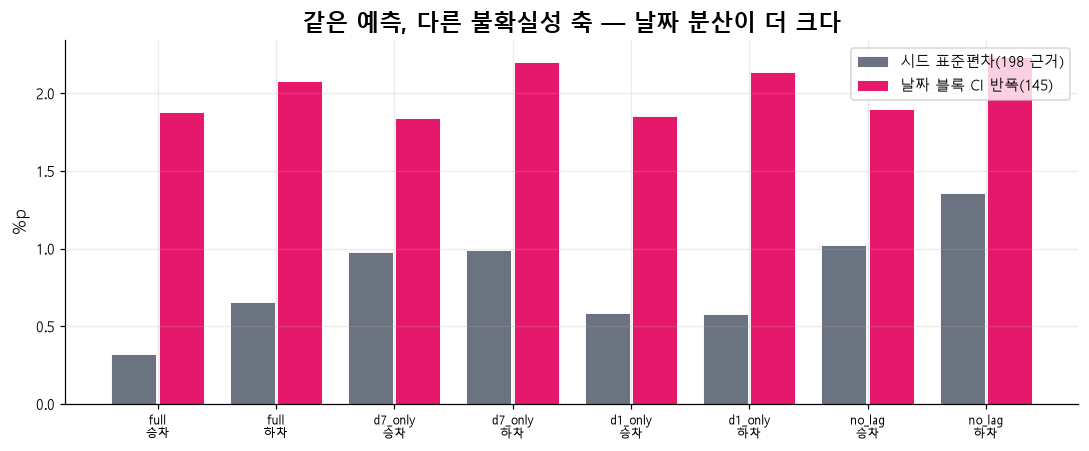

In [5]:
rows = []
for sc in SC:
    for t in TARGETS:
        g = tot_a[(tot_a["series"].isin(SEEDS)) & (tot_a["scenario"] == sc) & (tot_a["target"] == t)]
        rows.append({
            "scenario": sc, "target": KOR[t],
            "시드 평균": g["RMSE_개선율_%"].mean(),
            "시드 std": g["RMSE_개선율_%"].std(ddof=1),
            "날짜 CI 반폭(평균)": ((g["RMSE_CI_high"] - g["RMSE_CI_low"]) / 2).mean(),
            "하한>0 시드수": int((g["RMSE_CI_low"] > 0).sum()),
        })
spread = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4.2))
pos = np.arange(len(spread))
ax.bar(pos - 0.2, spread["시드 std"], 0.38, label="시드 표준편차(198 근거)",
       color=figstyle.PALETTE_NEUTRAL[1], edgecolor="white", linewidth=0.6)
ax.bar(pos + 0.2, spread["날짜 CI 반폭(평균)"], 0.38, label="날짜 블록 CI 반폭(145)",
       color=figstyle.COLOR_ACCENT, edgecolor="white", linewidth=0.6)
ax.set_xticks(pos)
ax.set_xticklabels([f"{r.scenario}\n{r.target}" for r in spread.itertuples()], fontsize=8)
ax.set_ylabel("%p")
ax.set_title("같은 예측, 다른 불확실성 축 — 날짜 분산이 더 크다")
ax.legend()
fig.tight_layout()
_ = figstyle.save(fig, "family_seed_vs_date")

print(spread.round(2).to_string(index=False))

## 5. 등급 일치율과 추론 시간

`full`에서 RMSE는 LightGBM이 앞서는데 **등급 일치율은 GRU가 0.2%p 높다** — 승하차 우열이 등급까지
그대로 가지 않는다(198에서 관찰된 방향이 199 배율표 판에서도 유지된다).

            cells  등급_일치율_%  보통이상_재현율_% scenario
run                                             
lookup    7798830    95.952      84.632     full
lightgbm  7798830    97.025      90.300     full
gru_s42   7798830    97.225      90.225     full
gru_s43   7798830    97.200      90.530     full
gru_s44   7798830    97.239      90.857     full


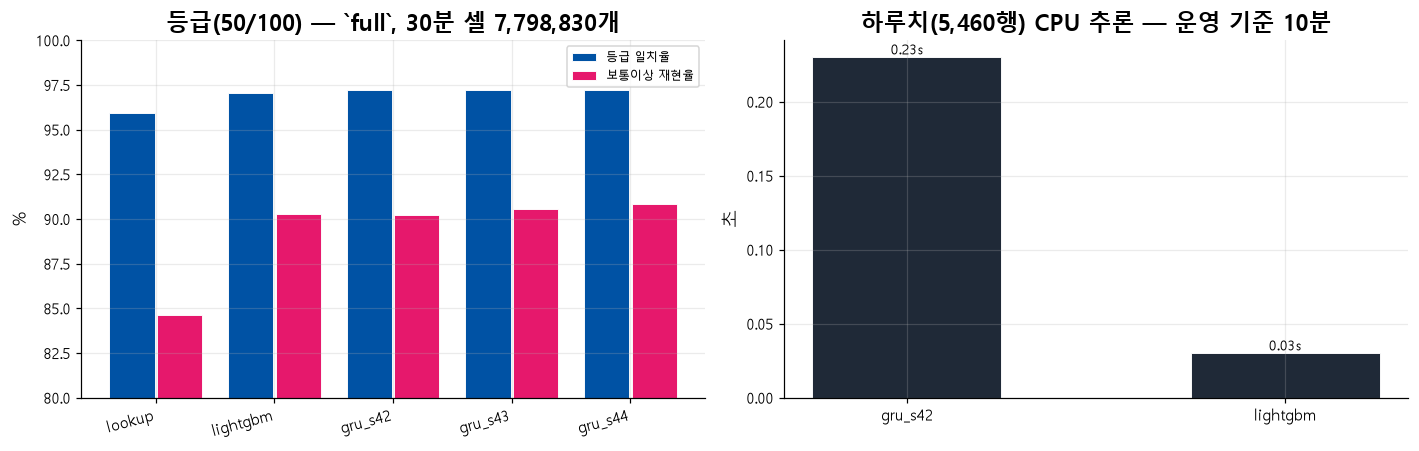

In [6]:
if d is None:
    print("등급 표 없음 — compare.py --grades full 로 먼저 만들 것")
else:
    dd = d.set_index("run").reindex(["lookup", "lightgbm", *SEEDS])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    pos = np.arange(len(dd))
    axes[0].bar(pos - 0.2, dd["등급_일치율_%"], 0.38, label="등급 일치율",
                color=figstyle.COLOR_MODEL, edgecolor="white", linewidth=0.6)
    axes[0].bar(pos + 0.2, dd["보통이상_재현율_%"], 0.38, label="보통이상 재현율",
                color=figstyle.COLOR_ACCENT, edgecolor="white", linewidth=0.6)
    axes[0].set_xticks(pos)
    axes[0].set_xticklabels(dd.index, rotation=15, ha="right")
    axes[0].set_ylim(80, 100)
    axes[0].set_ylabel("%")
    axes[0].set_title("등급(50/100) — `full`, 30분 셀 7,798,830개")
    axes[0].legend(fontsize=8)

    if e is None:
        axes[1].axis("off")
        axes[1].set_title("추론 시간 표 없음")
    else:
        ee = e.set_index("series")
        bars = axes[1].bar(np.arange(len(ee)), ee["seconds"], 0.5,
                           color=figstyle.PALETTE_NEUTRAL[0], edgecolor="white", linewidth=0.6)
        for rect, v in zip(bars, ee["seconds"]):
            axes[1].annotate(f"{v}s", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                             ha="center", va="bottom", fontsize=9)
        axes[1].set_xticks(np.arange(len(ee)))
        axes[1].set_xticklabels(ee.index)
        axes[1].set_ylabel("초")
        axes[1].set_title("하루치(5,460행) CPU 추론 — 운영 기준 10분")
    fig.tight_layout()
    _ = figstyle.save(fig, "family_grades_timing")
    print(dd.round(3).to_string())

## 6. 읽은 것

1. **단일 계열 교체는 기각 — `full`은 LightGBM 유지.** 쌍 차이 RMSE CI 하한이 −3.7~−4.4%p로
   교체 문턱(+2%p)에 크게 못 미치고, 1호선 −9.9%p·5호선 −5.0%p가 "어느 호선도 2%p 악화 없음"을 깬다.
2. **가용성별 다단 선택은 근거가 확보됐다(197로).** 결손 +10.6~+25.5%p, 전무 +38.9~+44.2%p로 CI
   하한이 모두 문턱 위다. LightGBM은 `d7_only` −20.8%, `no_lag` −36.6%로 lookup 아래로 떨어진다.
3. **`no_lag`에서 GRU가 lookup을 "넘는다"고는 못 한다.** 시드 3개 중 하나만 CI 하한이 0 위다 —
   채택 근거는 정확도 우위가 아니라 **붕괴하지 않는다**는 것이다(등급은 95.95 → 97.2로 오른다).
4. **시드 분산은 날짜 분산보다 작다**(4절). 198의 ±0.32~±1.02는 계열 판정 근거로 쓰기엔 좁았다.
5. **등급은 RMSE와 순서가 다르다** — `full`에서도 GRU가 등급 일치율 +0.2%p다. 한 지표만으로 계열을
   바꾸지 않는다는 규칙이 여기서 실제로 작동한다.